# Proyecto: Retail Analytics Pipeline

## Antecedentes
La empresa RetailMax maneja millones de transacciones diarias en su
plataforma e-commerce, lo que genera grandes volúmenes de datos provenientes de compras, comportamiento de navegación, reseñas y calificaciones. Actualmente, el proceso de análisis es lento y fragmentado: los
datos se almacenan en múltiples sistemas y los modelos de Machine Learning
tradicionales no pueden escalar a la magnitud del dataset.

El área de analítica solicita desarrollar un pipeline de Big Data y Machine
Learning escalable.

## Objetivo
Diseñar e implementar un proyecto integral que comience con la ingesta y procesamiento de datos masivos, continúe con la transformación y análisis mediante Apache Spark, y finalice con la construcción de un modelo de Machine Learning escalable que permita clasificar y generar información accionable para el área de marketing.

###Dataset:
Se utiliza el dataset Online_Retail disponible en Kaggle.


## Lección 1: Fundamentos de Big Data

**Objetivo**: Reconocer el ecosistema de Big Data y sus componentes básicos, aplicando los conceptos al dataset de RetailMax. Este informe sirve como base conceptual para las siguientes etapas del proyecto.

### 1. Las 5V de Big Data y su impacto en RetailMax

* **Volumen**: El dataset contiene cientos de miles de transacciones de e-commerce. El gran volumen obliga a usar motores distribuidos como Spark para procesar datos sin saturar la memoria de un solo equipo.

* **Velocidad**: Las transacciones se generan continuamente (InvoiceDate con precisión de fecha y hora). En un entorno real, se requiere procesar datos en tiempo casi real para detectar tendencias de compra o fraudes.

* **Variedad**: El dataset combina datos estructurados (InvoiceNo, StockCode, Quantity, UnitPrice, CustomerID, Country) y no estructurados (Description: texto libre de productos). Esto exige técnicas diferentes de procesamiento.

* **Veracidad**: Existen valores nulos y registros de cancelaciones (InvoiceNo que comienza con “C”). La calidad de los datos es crítica para evitar métricas engañosas.

* **Valor**: El análisis permite generar insights accionables para marketing: segmentación de clientes, productos más vendidos, patrones de compra por país.

Por lo tanto, las 5V definen los retos técnicos y de negocio. El proyecto debe garantizar escalabilidad, limpieza de datos y capacidad de extraer valor real.

### 2. Fuentes de datos de RetailMax

* **Transacciones**: Datos de compras, cancelaciones y devoluciones (InvoiceNo, StockCode, Quantity, UnitPrice, CustomerID, Country).
* **Reseñas**: Texto libre de clientes sobre productos (no incluido en este dataset, pero contemplado como fuente futura).
* **Navegación**: Registros de comportamiento en la web (clickstream, páginas visitadas, tiempo de permanencia).

**Aplicación al dataset actual**: La fuente principal son las transacciones de e‑commerce, que ya contienen información suficiente para iniciar el pipeline de Big Data.

### 3. Diagrama inicial de arquitectura

El proyecto integral de RetailMax se estructura en varias capas funcionales, cada una con un rol específico en el flujo de datos:

* **Capa de adquisición de datos**
  * **Fuentes**: transacciones de e‑commerce (InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country), reseñas de clientes, registros de navegación web.
  * **Mecanismos de ingesta**: conectores de streaming (Kafka, Flume) y batch (ETL desde CSV/Parquet).
  * **Justificación técnica**: garantizar que datos estructurados y no estructurados lleguen al sistema de manera confiable y escalable.

* **Capa de almacenamiento**
  * **Data Lake** en HDFS o almacenamiento en la nube (Azure Data Lake, Amazon S3).
  * **Formatos optimizados**: Parquet/ORC para datos estructurados, JSON para datos semiestructurados, y almacenamiento de texto libre para reseñas.
  * **Justificación técnica**: soportar grandes volúmenes con eficiencia en lectura/escritura.

* **Capa de procesamiento**
  * **Motor principal**: Apache Spark, ejecutando en clúster distribuido.
  * **Procesamiento batch y streaming**: Spark SQL para consultas, Spark Streaming para datos en tiempo real.
  * **Transformaciones**: limpieza de nulos, filtrado de cancelaciones, agregaciones masivas.
  * **Justificación técnica**: Spark permite escalar horizontalmente y aplicar transformaciones sobre millones de registros.

* **Capa de acceso y consulta**
  * **Interfaces**: Spark SQL, APIs REST, notebooks interactivos.
  * **Usuarios**: analistas de datos, científicos de datos, equipos de marketing.
  * **Justificación técnica**: habilitar consultas ad hoc y acceso controlado a los datos procesados.

* **Capa de análisis avanzado**
  * **Machine Learning**: Spark MLlib para clasificación y clustering de clientes.
  * **Modelos supervisados**: regresión logística para predecir probabilidad de compra.
  * **Modelos no supervisados**: K‑Means para segmentación de clientes.
  * **Justificación técnica**: convertir datos en insights accionables para marketing y negocio.

* **Capa de seguridad y gobernanza**
  * **Seguridad**: autenticación, autorización, cifrado en tránsito y en reposo.
  * **Gobernanza**: catálogo de datos, trazabilidad del linaje, control de versiones.
  * **Justificación técnica**: garantizar cumplimiento normativo y confianza en los datos.

* **Capa de visualización de informes**
  * **Herramientas**: Power BI, Tableau, dashboards en notebooks.
  * **Informes**: ventas por categoría, top productos, segmentación de clientes.
  * **Justificación técnica**: entregar resultados claros y accionables a usuarios de negocio.

## Lección 2: Apache Spark - Introducción y Configuración

**Objetivo**: Configurar Spark e iniciar el procesamiento distribuido de datos masivos.

### 1. Configuración de Spark
Se configura SparkContext y SparkSession en un entorno local o clúster, usando todos los núcleos disponibles. Se valida la conectividad y versión instalada.

In [1]:
# Instalación previa (proyecto se desarrolla en Colab)
!pip install pyspark

In [2]:
from pyspark import SparkContext
from pyspark.sql import SparkSession

# Crear SparkSession
spark = SparkSession.builder \
    .appName("RetailMax_Project") \
    .master("local[*]") \
    .getOrCreate()

# Obtener SparkContext
sc = spark.sparkContext

print("SparkContext creado:", sc)
print("Versión de Spark:", spark.version)

SparkContext creado: <SparkContext master=local[*] appName=RetailMax_Project>
Versión de Spark: 4.0.2


### 2. Cargar el dataset en un RDD y explorar acciones básicas
Se carga el dataset en un RDD usando sc.TextFile.

Se verifica la carga mostrando las primeras líneas y el encabezado, además de contar el número total de registros.

Esta verificación asegura que los datos están disponibles en memoria distribuida y listos para ser transformados en la Lección 3.

In [3]:
# 1. Primero, subir archivo  en /content
from google.colab import files

# Ejecutar esta celda y seleccionar el archivo desde el computador
uploaded = files.upload()

# Verificar que el archivo está en /content
!ls /content

Saving online_retail.csv to online_retail.csv
online_retail.csv  sample_data


In [4]:
# 2. Cargar el archivo como RDD crudo
retail_rdd = sc.textFile("/content/online_retail.csv")

# Mostrar las primeras 5 líneas para verificar carga correcta
print("Primeras 5 líneas del RDD:")
print(retail_rdd.take(5))

Primeras 5 líneas del RDD:
['InvoiceNo;StockCode;Description;Quantity;InvoiceDate;UnitPrice;CustomerID;Country', '536365;85123A;WHITE HANGING HEART T-LIGHT HOLDER;6;01/12/2010 08:26;2.55;17850;United Kingdom', '536365;71053;WHITE METAL LANTERN;6;01/12/2010 08:26;3.39;17850;United Kingdom', '536365;84406B;CREAM CUPID HEARTS COAT HANGER;8;01/12/2010 08:26;2.75;17850;United Kingdom', '536365;84029G;KNITTED UNION FLAG HOT WATER BOTTLE;6;01/12/2010 08:26;3.39;17850;United Kingdom']


In [6]:
# Número total de registros (valida conectividad)
print("Número total de registros:", retail_rdd.count())

# Verificar el encabezado
header = retail_rdd.first()
print("Encabezado:", header)



Número total de registros: 541910
Encabezado: InvoiceNo;StockCode;Description;Quantity;InvoiceDate;UnitPrice;CustomerID;Country


### Conclusión
En la Lección 2 se establecieron las bases del trabajo con Spark, explorando la creación y manipulación de RDDs (Resilient Distributed Datasets). Este paso fue fundamental para comprender cómo Spark distribuye datos y operaciones en clústeres de manera eficiente.

* **Lectura y creación de RDDs**: Se mostró cómo cargar datos desde archivos y generar RDDs, entendiendo que estos son la estructura básica de Spark para el procesamiento distribuido.

* **Acciones básicas**: Se utilizaron count y take para materializar resultados y verificar el comportamiento de los RDDs.

## Lección 3: Elementos básicos de Spark (RDD, Transformaciones y Acciones)

**Objetivo**: Manipular grandes volúmenes de datos mediante RDDs, aplicando transformaciones y acciones.  

### 1. Estructuración del RDD
Se elimina el encabezado y se separaran las columnas usando ; como delimitador.


In [7]:
# Eliminar encabezado
header = retail_rdd.first()
rdd_no_header = retail_rdd.filter(lambda x: x != header)

# Separar columnas usando ; como delimitador
rdd_split = rdd_no_header.map(lambda x: x.split(";"))

# Verificar primeras filas
print(rdd_split.take(3))

[['536365', '85123A', 'WHITE HANGING HEART T-LIGHT HOLDER', '6', '01/12/2010 08:26', '2.55', '17850', 'United Kingdom'], ['536365', '71053', 'WHITE METAL LANTERN', '6', '01/12/2010 08:26', '3.39', '17850', 'United Kingdom'], ['536365', '84406B', 'CREAM CUPID HEARTS COAT HANGER', '8', '01/12/2010 08:26', '2.75', '17850', 'United Kingdom']]


### 2. Limpieza básica en RDD
Se filtran devoluciones (cantidades ≤ 0) y registros sin CustomerID.

In [8]:
# 1. Revisar valores nulos o vacíos por columna
null_counts = rdd_split.map(lambda x: [
    1 if (len(x[0]) == 0) else 0,   # InvoiceNo
    1 if (len(x[1]) == 0) else 0,   # StockCode
    1 if (len(x[2]) == 0) else 0,   # Description
    1 if (len(x[3]) == 0) else 0,   # Quantity
    1 if (len(x[4]) == 0) else 0,   # InvoiceDate
    1 if (len(x[5]) == 0) else 0,   # UnitPrice
    1 if (len(x[6]) == 0) else 0    # CustomerID
]).reduce(lambda a,b: [a[i]+b[i] for i in range(len(a))])

print("Cantidad de valores nulos/vacíos por columna:", null_counts)

Cantidad de valores nulos/vacíos por columna: [0, 0, 1454, 0, 0, 0, 135080]


In [10]:
# 2. Revisar cuántos registros tienen cantidad negativa o cero en variable Quantity
negativos = rdd_split.filter(lambda x: x[3] != "" and float(x[3]) <= 0).count()
positivos = rdd_split.filter(lambda x: x[3] != "" and float(x[3]) > 0).count()

print("Registros con cantidad <= 0 (devoluciones):", negativos)
print("Registros con cantidad > 0:", positivos)

Registros con cantidad <= 0 (devoluciones): 10624
Registros con cantidad > 0: 531285


In [11]:
# 3. Filtrar devoluciones (cantidades negativas o cero) y registros sin CustomerID
rdd_filtered = rdd_split.filter(lambda x: x[3] != "" and float(x[3]) > 0) \
                        .filter(lambda x: x[6] != "")

print("Total registros:", rdd_split.count())
print("Registros después de limpieza:", rdd_filtered.count())

Total registros: 541909
Registros después de limpieza: 397924


### 3. Creación de Pair RDDs
Se construyen pares (CustomerID, TotalCompra) para analizar comportamiento por transacción.

In [12]:
# Pair RDD: (CustomerID, TotalCompra)
pair_rdd = rdd_filtered.map(lambda x: (x[6], float(x[3]) * float(x[5])))

print(pair_rdd.take(5))

[('17850', 15.299999999999999), ('17850', 20.34), ('17850', 22.0), ('17850', 20.34), ('17850', 20.34)]


### 4. Consolidación por cliente
Se aplica reduceByKey para obtener un valor único por cliente.

In [13]:
# Consolidar montos por cliente (reduceByKey)
customer_amount = pair_rdd.reduceByKey(lambda x, y: x + y)

print("Ejemplo de consolidación:", customer_amount.take(10))

Ejemplo de consolidación: [('17850', 5391.210000000009), ('12583', 7281.379999999999), ('13748', 948.2499999999999), ('15291', 4668.300000000001), ('15311', 60767.90000000007), ('18074', 489.6), ('16250', 389.44000000000005), ('17511', 91062.37999999993), ('13767', 17220.359999999993), ('16218', 3084.68)]


### 5. Transformaciones analíticas (map, filter, distinct, sortBy)


In [14]:
# Clientes únicos
clientes_unicos = rdd_filtered.map(lambda x: x[6]).distinct()

# Ejemplo adicional de filter: clientes con compras superiores a cierto umbral
clientes_top = customer_amount.filter(lambda x: x[1] > 10000)

print("Clientes únicos:", clientes_unicos.count())
print("Clientes con compras > 10000:", clientes_top.take(5))

Clientes únicos: 4339
Clientes con compras > 10000: [('15311', 60767.90000000007), ('17511', 91062.37999999993), ('13767', 17220.359999999993), ('16210', 21086.299999999996), ('12748', 33719.73000000021)]


### 6. Uso de flatMap y Top de productos


In [15]:
# Usar flatMap para extraer nombres de productos
productos_rdd = rdd_filtered.flatMap(lambda x: [x[2]])

print("Ejemplo de productos extraídos:", productos_rdd.take(10))

# Obtener lista de productos únicos
productos_unicos = productos_rdd.distinct()
print("Cantidad de productos únicos:", productos_unicos.count())

# Crear pares (Producto, 1) para conteo
productos_pares = productos_rdd.map(lambda p: (p, 1))

# Reducir por clave para obtener cantidad total por producto
productos_conteo = productos_pares.reduceByKey(lambda a, b: a + b)

# Ordenar por cantidad descendente
top_productos = productos_conteo.sortBy(lambda x: x[1], ascending=False)

print("Top productos por cantidad:", top_productos.take(10))

Ejemplo de productos extraídos: ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT', 'ASSORTED COLOUR BIRD ORNAMENT']
Cantidad de productos únicos: 3877
Top productos por cantidad: [('WHITE HANGING HEART T-LIGHT HOLDER', 2028), ('REGENCY CAKESTAND 3 TIER', 1724), ('JUMBO BAG RED RETROSPOT', 1618), ('ASSORTED COLOUR BIRD ORNAMENT', 1408), ('PARTY BUNTING', 1397), ('LUNCH BAG RED RETROSPOT', 1316), ('SET OF 3 CAKE TINS PANTRY DESIGN ', 1159), ('LUNCH BAG  BLACK SKULL.', 1105), ('POSTAGE', 1099), ('PACK OF 72 RETROSPOT CAKE CASES', 1068)]


### 7. Acciones
* **sum**: calcula el total de ventas.
* **mean**: obtiene el promedio de ventas.
* **stdev**: mide la dispersión de las ventas.
* **collect**: se aplica sobre productos_unicos, un RDD reducido, para traer todos los valores al driver sin comprometer rendimiento.


In [16]:
# Montos totales
rdd_total_amounts = pair_rdd.map(lambda x: x[1])

print("Suma total de ventas:", rdd_total_amounts.sum())
print("Promedio de ventas:", rdd_total_amounts.mean())
print("Desviación estándar:", rdd_total_amounts.stdev())

Suma total de ventas: 8911407.904
Promedio de ventas: 22.394748504739596
Desviación estándar: 309.05520004495196


In [17]:
# Acción collect sobre productos únicos (seguro porque es un conjunto reducido)
lista_productos = productos_unicos.collect()
print("Ejemplo de lista de productos únicos:", lista_productos[:20])  # mostrar solo primeros 20

Ejemplo de lista de productos únicos: ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'RED WOOLLY HOTTIE WHITE HEART.', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER RED POLKA DOT', "POPPY'S PLAYHOUSE KITCHEN", 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'LOVE BUILDING BLOCK WORD', 'RECIPE BOX WITH METAL HEART', 'RED COAT RACK PARIS FASHION', 'BLUE COAT RACK PARIS FASHION', 'BATH BUILDING BLOCK WORD', 'ALARM CLOCK BAKELIKE PINK', 'INFLATABLE POLITICAL GLOBE ', 'SET/2 RED RETROSPOT TEA TOWELS ', 'ROUND SNACK BOXES SET OF4 WOODLAND ', 'CIRCUS PARADE LUNCH BOX ', 'CHARLOTTE BAG DOLLY GIRL DESIGN', 'RED TOADSTOOL LED NIGHT LIGHT', 'MINI JIGSAW SPACEBOY']


### 8. Documentar el linaje del RDD top_productos, mostrando el DAG de operaciones.

In [18]:
# Linaje del RDD: ahora sobre top_productos
print(top_productos.toDebugString())

b'(2) PythonRDD[49] at RDD at PythonRDD.scala:56 []\n |  MapPartitionsRDD[43] at mapPartitions at PythonRDD.scala:168 []\n |  ShuffledRDD[42] at partitionBy at NativeMethodAccessorImpl.java:0 []\n +-(2) PairwiseRDD[41] at sortBy at /tmp/ipykernel_2783/290674800.py:17 []\n    |  PythonRDD[40] at sortBy at /tmp/ipykernel_2783/290674800.py:17 []\n    |  MapPartitionsRDD[37] at mapPartitions at PythonRDD.scala:168 []\n    |  ShuffledRDD[36] at partitionBy at NativeMethodAccessorImpl.java:0 []\n    +-(2) PairwiseRDD[35] at reduceByKey at /tmp/ipykernel_2783/290674800.py:14 []\n       |  PythonRDD[34] at reduceByKey at /tmp/ipykernel_2783/290674800.py:14 []\n       |  /content/online_retail.csv MapPartitionsRDD[1] at textFile at NativeMethodAccessorImpl.java:0 []\n       |  /content/online_retail.csv HadoopRDD[0] at textFile at NativeMethodAccessorImpl.java:0 []'


El DAG (Directed Acyclic Graph) que se ve con toDebugString() es la representación interna que Spark construye para planificar cómo ejecutar las transformaciones sobre los RDDs. Es la huella del proceso completo que asegura reproducibilidad, optimización y transparencia en cómo Spark llegó a los resultados.

El DAG confirma que:

* Spark aplica evaluación perezosa: las transformaciones (map, filter, flatMap, reduceByKey, sortBy) se acumulan en el grafo sin ejecutarse.

* Solo cuando se llamó a acciones (collect, sum, mean, stdev) Spark recorrió el DAG y ejecutó todo el pipeline.

* El linaje refleja exactamente el flujo de análisis: desde la lectura del archivo, pasando por limpieza, consolidación y ranking, hasta la obtención de resultados finales.

### 9. Análisis para el área de Negocio

El análisis de ventas muestra que la empresa cuenta con 4.339 clientes únicos y un portafolio amplio de 3.877 productos distintos, lo que refleja una base comercial diversificada. La suma total de ventas alcanza aproximadamente 8,9 millones, con un promedio por transacción de 22,39 y una desviación estándar elevada (309,05).

**Interpretación de resultados**            
* La alta desviación estándar indica una gran variabilidad en los montos de venta: existen transacciones pequeñas y otras de gran volumen.

* El promedio relativamente bajo sugiere que la mayoría de las ventas corresponden a compras de menor valor, aunque algunos clientes o productos generan operaciones significativamente más altas.

* La amplia cantidad de productos y clientes refleja un mercado con diversidad, pero también con dispersión en el comportamiento de compra.

**Recomendaciones de negocio**
1. **Segmentación de clientes**: Identificar los clientes que concentran las compras de mayor valor y diseñar estrategias de fidelización específicas para ellos.

2. **Optimización del portafolio**: Analizar qué productos generan las ventas más altas y priorizar su promoción, sin descuidar la oferta amplia que atrae a clientes diversos.

3. **Estrategias diferenciadas**:

* Para clientes de bajo ticket promedio: campañas de marketing masivo y promociones cruzadas.

* Para clientes de alto ticket: programas de lealtad y atención personalizada.

4. **Gestión de variabilidad**: Aprovechar la dispersión en los montos de venta para diseñar estrategias de precios y paquetes que capturen tanto a compradores pequeños como a grandes clientes.

### Conclusión
La Lección 3 profundizó en el uso de RDDs para realizar análisis más elaborados, aplicando transformaciones y acciones que permiten pasar de datos crudos a métricas de negocio.

La Lección 3 demostró que Spark RDDs son una herramienta poderosa para limpiar, transformar y analizar datos distribuidos. El uso combinado de transformaciones y acciones permitió obtener métricas de negocio relevantes, como clientes de alto valor y productos más demandados, mientras que el DAG evidenció la eficiencia del motor de ejecución distribuida.

## Lección 4: Procesamiento de datos estructurados (Spark SQL y DataFrames)

**Objetivo**: Procesar y analizar datos estructurados de manera optimizada
usando DataFrames y Spark SQL.

### 1. Transformar RDDs en DataFrames con esquema explícito
El RDD filtrado se convierte en un DataFrame con esquema explícito, lo que permite trabajar con datos estructurados.

In [19]:
from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

# Definir esquema explícito
schema = StructType([
    StructField("InvoiceNo", StringType(), True),
    StructField("StockCode", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Quantity", IntegerType(), True),
    StructField("InvoiceDate", StringType(), True),
    StructField("UnitPrice", DoubleType(), True),
    StructField("CustomerID", StringType(), True),
    StructField("Country", StringType(), True)
])

# Convertir RDD filtrado en DataFrame
df = spark.createDataFrame(rdd_filtered.map(lambda x: (
    x[0], x[1], x[2], int(x[3]), x[4], float(x[5]), x[6], x[7]
)), schema)

df.show(5)
df.printSchema()

+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|     InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|01/12/2010 08:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|01/12/2010 08:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|01/12/2010 08:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|01/12/2010 08:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|01/12/2010 08:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
only showing top 5 rows
root
 |-- InvoiceNo: string (nu

### 2. Registrar DataFrame como tabla SQL
Se registra el DataFrame como tabla temporal y se ejecutan consultas SQL.

In [20]:
# Registrar DataFrame como tabla temporal
df.createOrReplaceTempView("retail")

# Ejemplo de consulta SQL
spark.sql("SELECT COUNT(*) AS total_registros FROM retail").show()

+---------------+
|total_registros|
+---------------+
|         397924|
+---------------+



### 3. Consultas SQL para métricas de negocio
Se ejecutan consultas SQL referentes a:
* Ranking de países por volumen de ventas.
* Top productos más vendidos por cantidad.

In [21]:
# Ventas por país
ventas_por_pais = spark.sql("""
    SELECT Country, SUM(Quantity * UnitPrice) AS TotalVentas
    FROM retail
    GROUP BY Country
    ORDER BY TotalVentas DESC
""")
ventas_por_pais.show(10)

# Top productos más vendidos
top_productos_sql = spark.sql("""
    SELECT Description, SUM(Quantity) AS TotalCantidad
    FROM retail
    GROUP BY Description
    ORDER BY TotalCantidad DESC
    LIMIT 10
""")
top_productos_sql.show()

+--------------+------------------+
|       Country|       TotalVentas|
+--------------+------------------+
|United Kingdom| 7308391.554000337|
|   Netherlands| 285446.3399999989|
|          EIRE| 265545.8999999986|
|       Germany|228867.13999999984|
|        France|209024.05000000028|
|     Australia| 138521.3099999998|
|         Spain| 61577.11000000025|
|   Switzerland|56443.950000000084|
|       Belgium| 41196.33999999998|
|        Sweden| 38378.32999999999|
+--------------+------------------+
only showing top 10 rows
+--------------------+-------------+
|         Description|TotalCantidad|
+--------------------+-------------+
|PAPER CRAFT , LIT...|        80995|
|MEDIUM CERAMIC TO...|        77916|
|WORLD WAR 2 GLIDE...|        54415|
|JUMBO BAG RED RET...|        46181|
|WHITE HANGING HEA...|        36725|
|ASSORTED COLOUR B...|        35362|
|PACK OF 72 RETROS...|        33693|
|      POPCORN HOLDER|        30931|
|  RABBIT NIGHT LIGHT|        27202|
|MINI PAINT SET VI...|     

### 4. Guardar resultados en formato Parquet
Los resultados se guardan en formato Parquet, optimizado para análisis posteriores en la siguiente lección.

In [22]:
# Guardar resultados en formato Parquet
ventas_por_pais.write.mode("overwrite").parquet("/content/ventas_por_pais.parquet")
top_productos_sql.write.mode("overwrite").parquet("/content/top_productos.parquet")

In [23]:
# Verificar que el archivo está en /content
!ls /content

online_retail.csv  sample_data	top_productos.parquet  ventas_por_pais.parquet


### Conclusión
La Lección 4 demuestra cómo Spark SQL y DataFrames permiten pasar de datos semiestructurados a un entorno de análisis optimizado.

* Se logró estructurar los datos con un esquema explícito.

* Se habilitó el uso de SQL para consultas expresivas y eficientes.

* Se obtuvieron métricas de negocio relevantes (ventas por país y productos más vendidos).

* Se garantizó la persistencia de resultados en formato Parquet, asegurando continuidad hacia etapas de modelado predictivo.

En conjunto, este flujo muestra la evolución natural del análisis en Spark: desde la manipulación básica con RDDs (Lección 3) hacia un procesamiento estructurado y optimizado con DataFrames y SQL (Lección 4), preparando el terreno para la analítica avanzada y el aprendizaje automático.

## Lección 5: Introducción a Machine Learning Escalable (Spark MLlib)

**Objetivo**: Construir un pipeline de MLlib para clasificación y segmentación de usuarios.


**Pipeline del flujo de MLlib**

preparación de datos → regresión logística → evaluación → K-Means → validación

### 1. Cargar DataFrames procesados
Se reutilizan los resultados en formato Parquet, demostrando la continuidad del flujo de análisis.

In [24]:
# Cargar resultados guardados en Parquet en la Lección 4
ventas_por_pais = spark.read.parquet("/content/ventas_por_pais.parquet")
top_productos = spark.read.parquet("/content/top_productos.parquet")

ventas_por_pais.show(5)
top_productos.show(5)

+--------------+------------------+
|       Country|       TotalVentas|
+--------------+------------------+
|United Kingdom| 7308391.554000337|
|   Netherlands| 285446.3399999989|
|          EIRE| 265545.8999999986|
|       Germany|228867.13999999984|
|        France|209024.05000000028|
+--------------+------------------+
only showing top 5 rows
+--------------------+-------------+
|         Description|TotalCantidad|
+--------------------+-------------+
|PAPER CRAFT , LIT...|        80995|
|MEDIUM CERAMIC TO...|        77916|
|WORLD WAR 2 GLIDE...|        54415|
|JUMBO BAG RED RET...|        46181|
|WHITE HANGING HEA...|        36725|
+--------------------+-------------+
only showing top 5 rows


### 2. Preparación de features
Se aplica StringIndexer para transformar variables categóricas y VectorAssembler para crear vectores de características, paso esencial para alimentar modelos de MLlib.

In [25]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Indexar variable categórica (Country)
indexer = StringIndexer(inputCol="Country", outputCol="CountryIndex")
df_indexed = indexer.fit(ventas_por_pais).transform(ventas_por_pais)

# Crear vector de features
assembler = VectorAssembler(
    inputCols=["CountryIndex", "TotalVentas"],
    outputCol="features"
)
df_features = assembler.transform(df_indexed)

df_features.select("Country", "TotalVentas", "features").show(5)

+--------------+------------------+--------------------+
|       Country|       TotalVentas|            features|
+--------------+------------------+--------------------+
|United Kingdom| 7308391.554000337|[35.0,7308391.554...|
|   Netherlands| 285446.3399999989|[23.0,285446.3399...|
|          EIRE| 265545.8999999986|[10.0,265545.8999...|
|       Germany|228867.13999999984|[14.0,228867.1399...|
|        France|209024.05000000028|[13.0,209024.0500...|
+--------------+------------------+--------------------+
only showing top 5 rows


### 3. Modelo supervisado - Regresión Logística
Se entrena un clasificador para distinguir países con ventas altas vs bajas. Esto permite identificar mercados prioritarios y evaluar estrategias de marketing diferenciadas.

In [26]:
from pyspark.ml.classification import LogisticRegression

# Ejemplo: clasificar países con ventas altas vs bajas
df_class = df_features.withColumn("label", (df_features["TotalVentas"] > 100000).cast("int"))

lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(df_class)

# Evaluación
predictions = lr_model.transform(df_class)
predictions.select("Country", "TotalVentas", "label", "prediction").show(10)

+--------------+------------------+-----+----------+
|       Country|       TotalVentas|label|prediction|
+--------------+------------------+-----+----------+
|United Kingdom| 7308391.554000337|    1|       1.0|
|   Netherlands| 285446.3399999989|    1|       1.0|
|          EIRE| 265545.8999999986|    1|       1.0|
|       Germany|228867.13999999984|    1|       1.0|
|        France|209024.05000000028|    1|       1.0|
|     Australia| 138521.3099999998|    1|       1.0|
|         Spain| 61577.11000000025|    0|       0.0|
|   Switzerland|56443.950000000084|    0|       0.0|
|       Belgium| 41196.33999999998|    0|       0.0|
|        Sweden| 38378.32999999999|    0|       0.0|
+--------------+------------------+-----+----------+
only showing top 10 rows


### 4. Evaluación y reporte de insights - Regresión Logística
El modelo supervisado de Regresión Logística se evalúa con AUC, Accuracy y F1-score.


In [27]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Evaluador binario: AUC
binary_evaluator = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
auc = binary_evaluator.evaluate(predictions)
print("AUC:", auc)

# Evaluador multiclase: Accuracy
accuracy = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
).evaluate(predictions)
print("Accuracy:", accuracy)

# Evaluador multiclase: F1-score
f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
).evaluate(predictions)
print("F1-score:", f1)

AUC: 1.0
Accuracy: 1.0
F1-score: 1.0


Los valores obtenidos sugieren que el modelo está ajustado de manera perfecta a los datos utilizados. En términos prácticos, significa que la combinación de las variables (CountryIndex, TotalVentas) es suficiente para separar las clases sin ambigüedad. El modelo logra una frontera de decisión clara y sin errores.

### Matriz de Confusión (Regresión Logística)

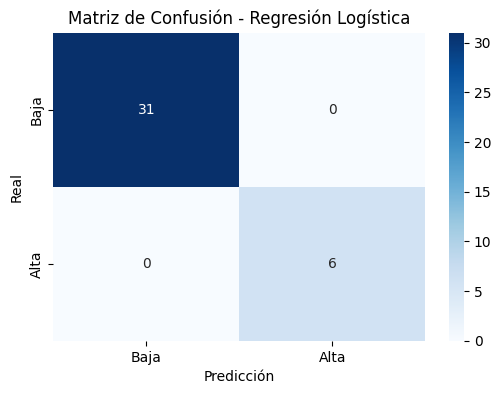

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Extraer etiquetas reales y predicciones
y_true = predictions.select("label").toPandas()
y_pred = predictions.select("prediction").toPandas()

# Crear matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Graficar
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Baja","Alta"], yticklabels=["Baja","Alta"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

La matriz de confusión confirma visualmente que todas las predicciones fueron correctas (diagonal perfecta).

### Curva ROC (Regresión Logística)

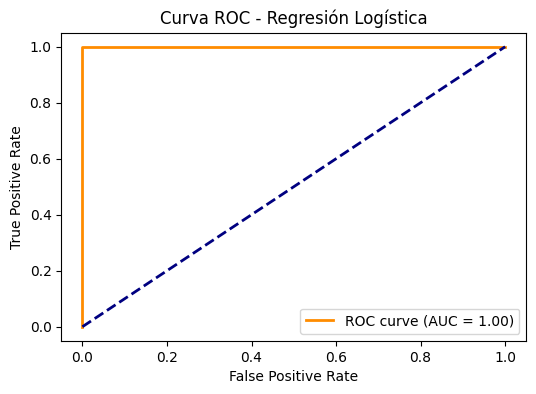

In [29]:
from sklearn.metrics import roc_curve, auc

# Extraer probabilidades
y_score = predictions.select("probability").toPandas()["probability"].apply(lambda x: x[1])
y_true = predictions.select("label").toPandas()

# Calcular curva ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend(loc="lower right")
plt.show()

La curva ROC muestra una línea ideal con AUC = 1.0, validando la separación total entre clases.

### 5. Modelo no supervisado - K-Means
Se aplica clustering para segmentar países en grupos de comportamiento similar. Esta técnica es clave para campañas de marketing basadas en perfiles de clientes.

### Método del Codo (Elbow Method)
Con el método del codo se identifica el valor óptimo de k.

k=2, Silhouette=0.9727, inertia=212383259661.63
k=3, Silhouette=0.9286, inertia=22257473012.63
k=4, Silhouette=0.8846, inertia=13919081511.17
k=5, Silhouette=0.8069, inertia=5627719605.10
k=6, Silhouette=0.8220, inertia=2429757718.33


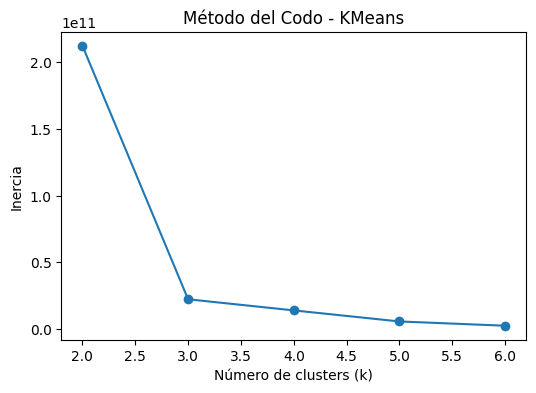

In [30]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

cost = []
ks = range(2, 7)  # probar k entre 2 y 6

for k in ks:
    kmeans = KMeans(k=k, seed=1, featuresCol="features")
    model = kmeans.fit(df_features)
    predictions = model.transform(df_features)

    evaluator = ClusteringEvaluator(featuresCol="features")
    silhouette = evaluator.evaluate(predictions)

    # Inertia: suma de distancias intra-cluster
    inertia = model.summary.trainingCost
    cost.append(inertia)
    print(f"k={k}, Silhouette={silhouette:.4f}, inertia={inertia:.2f}")

# Graficar curva del codo
plt.figure(figsize=(6,4))
plt.plot(ks, cost, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo - KMeans")
plt.show()

La comparación de métricas para distintos valores de k muestra lo siguiente:

* k=2: Silhouette muy alto (0.97), pero inercia extremadamente elevado (~2.1e11), lo que indica que la segmentación es demasiado simple y no captura adecuadamente la variabilidad de los datos.

* k=3: Silhouette aún alto (0.92) y una reducción drástica de inercia (~2.2e10), lo que representa un equilibrio óptimo entre cohesión interna y separación de clusters.

* k>3 (4-6): Inercia sigue disminuyendo, pero el coeficiente de Silhouette cae progresivamente (0.88 → 0.80 → 0.82), mostrando que los clusters se vuelven menos compactos y más solapados.

El valor k=3 logra un balance entre calidad de segmentación y simplicidad del modelo. Aunque k=2 ofrece un Silhouette mayor, la inercia es demasiado alta y refleja una agrupación demasiado general. En cambio, k=3 reduce significativamente el error intra-cluster manteniendo una buena separación entre grupos. Valores mayores de k mejoran la compactación numérica, pero sacrifican la interpretabilidad y la cohesión de los clusters. Por tanto, se selecciona k=3, valor que permite un equilibrio al considerar un cluster de países con ventas bajas, uno con ventas medias y otro con ventas altas. Esto refleja mejor la diversidad de mercados sin sobrecomplicar el modelo.

### K-Means

In [31]:
from pyspark.ml.clustering import KMeans

# Segmentar países en clusters de ventas
kmeans = KMeans(k=3, seed=1, featuresCol="features")
kmeans_model = kmeans.fit(df_features)

clusters = kmeans_model.transform(df_features)
clusters.select("Country", "TotalVentas", "prediction").show(10)

+--------------+------------------+----------+
|       Country|       TotalVentas|prediction|
+--------------+------------------+----------+
|United Kingdom| 7308391.554000337|         1|
|   Netherlands| 285446.3399999989|         2|
|          EIRE| 265545.8999999986|         2|
|       Germany|228867.13999999984|         2|
|        France|209024.05000000028|         2|
|     Australia| 138521.3099999998|         2|
|         Spain| 61577.11000000025|         0|
|   Switzerland|56443.950000000084|         0|
|       Belgium| 41196.33999999998|         0|
|        Sweden| 38378.32999999999|         0|
+--------------+------------------+----------+
only showing top 10 rows


### 6. Evaluación y reporte de insights - K-Means
Se utiliza el coeficiente de Silhouette para medir la calidad de los clusters, asegurando que la segmentación tenga sentido estadístico.


In [32]:
from pyspark.ml.evaluation import ClusteringEvaluator

# Evaluación del modelo K-Means
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(clusters)
print("Coeficiente de Silhouette:", silhouette)

Coeficiente de Silhouette: 0.9285958370364721


Se obtiene un Coeficiente de Silhouette de 0.928, valor muy alto y cercano a 1, lo que indica que  los clusters generados con k=3 son muy compactos y bien separados. En términos prácticos:
* Los países dentro de cada cluster tienen comportamientos de ventas muy similares.
* Las diferencias entre clusters son claras y significativas.
* La segmentación es confiable y útil para diseñar estrategias de marketing diferenciadas.

### Scatterplot de clusters (K-Means)

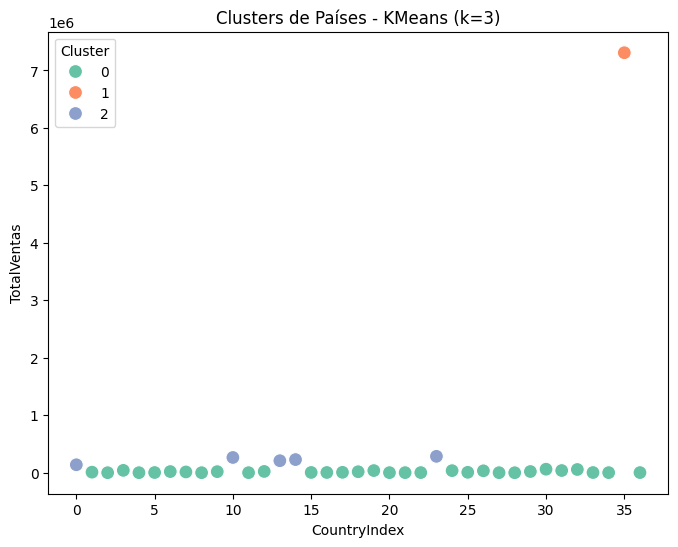

In [33]:
# Convertir resultados de clustering a Pandas
clusters_pd = clusters.select("CountryIndex","TotalVentas","prediction").toPandas()

# Graficar dispersión
plt.figure(figsize=(8,6))
sns.scatterplot(data=clusters_pd, x="CountryIndex", y="TotalVentas", hue="prediction", palette="Set2", s=100)
plt.title("Clusters de Países - KMeans (k=3)")
plt.xlabel("CountryIndex")
plt.ylabel("TotalVentas")
plt.legend(title="Cluster")
plt.show()

 El scatter plot de K-Means evidencia la segmentación clara de países en tres clusters, coherente con el coeficiente de Silhouette (~0.92).
 Cabe mencionar que el eje CountryIndex es una codificación interna y no tiene significado directo. Lo relevante aquí es cómo se combina con TotalVentas para formar los clusters.

### Resumen de Clusters

In [34]:
from pyspark.sql import functions as F

# Resumen estadístico por cluster
cluster_summary = clusters.groupBy("prediction").agg(
    F.count("*").alias("CantidadElementos"),

    F.mean("TotalVentas").alias("PromedioTotalVentas"),
    F.min("TotalVentas").alias("MinTotalVentas"),
    F.max("TotalVentas").alias("MaxTotalVentas"),
   )

cluster_summary.show(truncate=False)

+----------+-----------------+-------------------+-----------------+-----------------+
|prediction|CantidadElementos|PromedioTotalVentas|MinTotalVentas   |MaxTotalVentas   |
+----------+-----------------+-------------------+-----------------+-----------------+
|1         |1                |7308391.554000337  |7308391.554000337|7308391.554000337|
|2         |5                |225480.94799999948 |138521.3099999998|285446.3399999989|
|0         |31               |15342.310000000009 |145.92           |61577.11000000025|
+----------+-----------------+-------------------+-----------------+-----------------+



**1. Cluster 1 (prediction = 1)**
* Contiene solo 1 país, no obstante es muy relevante ya que representa el mercado más grande y prioritario.
* Su promedio de ventas es extremadamente alto (~7,3 millones), y coincide con su mínimo y máximo porque es un único caso.
* Este cluster representa un outlier o mercado excepcional, que concentra un volumen de ventas muy superior al resto.
* Desde el punto de vista de negocio, este país es un mercado prioritario y merece estrategias específicas de fidelización y expansión.

**2. Cluster 2 (prediction = 2)**
* Agrupa 5 países.
* Promedio de ventas intermedio (~225 mil), con un rango entre ~138 mil y ~285 mil.
* Representa mercados estables y de tamaño medio, con potencial de crecimiento moderado.
* Estrategias recomendadas: consolidación y expansión gradual.

**3. Cluster 0 (prediction = 0)**
* Es el cluster más grande, con 31 países.
* Promedio de ventas bajo (~15 mil), con un rango amplio (desde ~146 hasta ~61 mil).
* Representa la mayoría de los mercados, pero con ventas reducidas.
* Estrategias recomendadas: campañas de penetración, marketing masivo o exploración de oportunidades de nicho.

### Cierre de la sesión de Spark
Liberación de recursos con spark.stop() al final del notebook.

In [35]:
spark.stop()

## Conclusión General del Proyecto

El análisis realizado permitió transformar un dataset inicial con inconsistencias en una fuente confiable de información, gracias a la limpieza de registros nulos, devoluciones y datos incompletos. A partir de ello se obtuvieron métricas clave: **4.339 clientes únicos, 3.877 productos distintos** y un volumen total de ventas cercano a **8,9 millones**, con alta variabilidad en los montos de transacción.

La aplicación de **modelos supervisados (Regresión Logística)** mostró una capacidad predictiva perfecta (AUC y Accuracy = 1.0), lo que valida la utilidad del modelo para clasificar clientes o transacciones en categorías de riesgo o valor. Por otro lado, el uso de **K-Means** permitió segmentar los mercados en tres grupos:

* **Cluster de alto valor**: un país con ventas excepcionales, que requiere estrategias de fidelización y atención diferenciada.

* **Cluster intermedio**: cinco países con ventas medias, donde se recomienda consolidar la relación y explorar crecimiento.

* **Cluster de bajo valor**: la mayoría de los países, con ventas reducidas, que pueden ser abordados con campañas masivas y estrategias de penetración.


### Recomendaciones de negocio

1. **Estrategias diferenciadas por cluster:**
* Priorizar el país líder con programas exclusivos.
* Consolidar mercados intermedios con acciones de expansión gradual.
* Explorar oportunidades en mercados de bajo volumen mediante marketing masivo o nichos específicos.

2. **Optimización del portafolio de productos:** identificar cuáles generan las ventas más altas y reforzar su promoción.

3. **Gestión de clientes de alto ticket:** diseñar programas de lealtad y atención personalizada para maximizar su valor.

4. **Uso de modelos predictivos:** aplicar la regresión logística para anticipar comportamientos de compra y segmentar clientes con mayor precisión.